# Chapter 4 - Question 14: Auto Dataset Classification


## Part (a): Create binary variable mpg01

Create a binary variable, mpg01, that contains a 1 if mpg contains
 a value above its median, and a 0 if mpg contains a value below
 its median. You can compute the median using the median()
 method of the data frame. Note you may find it helpful to add
 a column mpg01 to the data frame by assignment. Assuming you
 have stored the data frame as Auto, this can be done as follows:
 Auto['mpg01'] = mpg01

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Load the Auto dataset
from ISLP import load_data
Auto = load_data('Auto')

# Display basic information about the dataset
print("Auto dataset shape:", Auto.shape)
print("\nFirst few rows:")
print(Auto.head())
print("\nDataset info:")
print(Auto.info())
print("\nBasic statistics:")
print(Auto.describe())

Auto dataset shape: (392, 8)

First few rows:
                            mpg  cylinders  displacement  horsepower  weight  \
name                                                                           
chevrolet chevelle malibu  18.0          8         307.0         130    3504   
buick skylark 320          15.0          8         350.0         165    3693   
plymouth satellite         18.0          8         318.0         150    3436   
amc rebel sst              16.0          8         304.0         150    3433   
ford torino                17.0          8         302.0         140    3449   

                           acceleration  year  origin  
name                                                   
chevrolet chevelle malibu          12.0    70       1  
buick skylark 320                  11.5    70       1  
plymouth satellite                 11.0    70       1  
amc rebel sst                      12.0    70       1  
ford torino                        10.5    70       1  



In [3]:
# Create binary variable mpg01
mpg_median = Auto['mpg'].median()
print(f"Median MPG: {mpg_median}")

# Create mpg01: 1 if mpg > median, 0 if mpg <= median
mpg01 = (Auto['mpg'] > mpg_median).astype(int)
Auto['mpg01'] = mpg01

print(f"\nDistribution of mpg01:")
print(Auto['mpg01'].value_counts())
print(f"\nProportion:")
print(Auto['mpg01'].value_counts(normalize=True))

Median MPG: 22.75

Distribution of mpg01:
mpg01
0    196
1    196
Name: count, dtype: int64

Proportion:
mpg01
0    0.5
1    0.5
Name: proportion, dtype: float64


## Part (b): Explore the data graphically

Explore the data graphically in order to investigate the associ
ation between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scat
terplots and boxplots may be useful tools to answer this ques
tion. Describe your findings.

In [4]:
# Calculate correlation with mpg01
numeric_cols = Auto.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('mpg')  # Remove original mpg as it's directly related to mpg01

correlations = Auto[numeric_cols].corrwith(Auto['mpg01']).sort_values(ascending=False)
print("Correlation with mpg01:")
print(correlations)

Correlation with mpg01:
mpg01           1.000000
origin          0.513698
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
dtype: float64


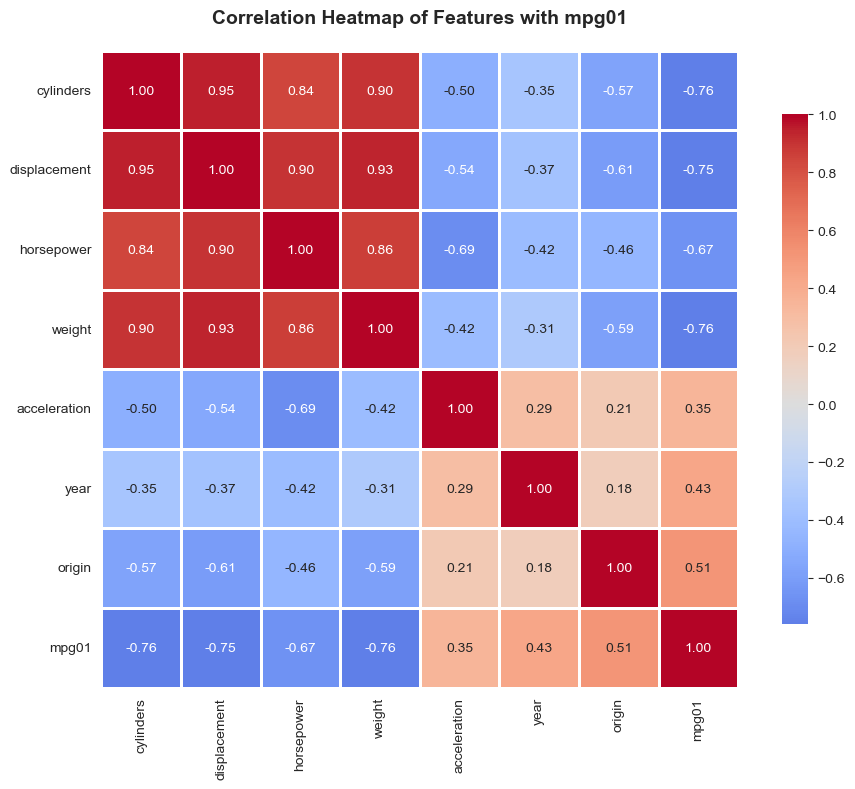

In [17]:
# Create correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = Auto[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Features with mpg01', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

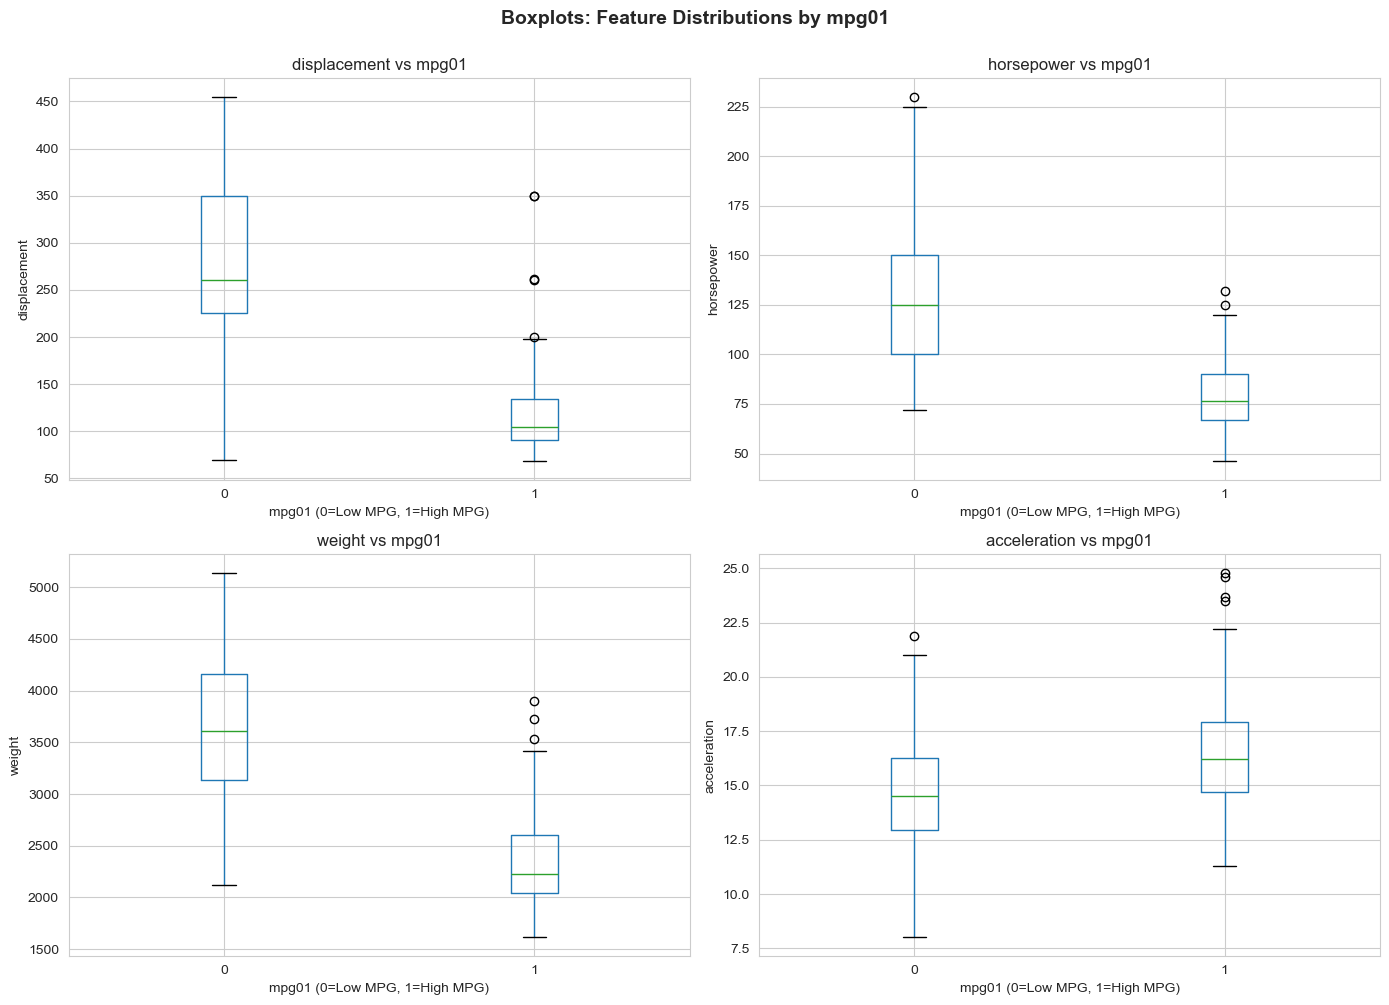

In [13]:
# Create boxplots for key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

key_features = ['displacement', 'horsepower', 'weight', 'acceleration']

for idx, feature in enumerate(key_features):
    Auto.boxplot(column=feature, by='mpg01', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs mpg01')
    axes[idx].set_xlabel('mpg01 (0=Low MPG, 1=High MPG)')
    axes[idx].set_ylabel(feature)

plt.suptitle('Boxplots: Feature Distributions by mpg01', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Findings:

**Most useful features for predicting mpg01:**
- **cylinders** (-0.76), **weight** (-0.76), **displacement** (-0.75): Strongest negative correlations
- **origin** (+0.51), **year** (+0.43), **acceleration** (+0.35): Positive correlations

**From visualizations:**
- Heatmap reveals strong multicollinearity among cylinders, weight, displacement, and horsepower
- Boxplots show clear separation between high/low MPG groups for engine-related features
- Low MPG cars: heavier, larger engines, more cylinders, more horsepower
- High MPG cars: lighter, smaller engines, better acceleration

**Selected features:** displacement, horsepower, weight, acceleration

## Part (c): Split data into training and test sets

In [6]:
# Select features based on EDA
selected_features = ['displacement', 'horsepower', 'weight', 'acceleration']

# Prepare X and y
X = Auto[selected_features]
y = Auto['mpg01']

# Split the data: 70% training, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Data split complete!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Data split complete!
Training set size: 274 samples
Test set size: 118 samples

Training set class distribution:
mpg01
0    137
1    137
Name: count, dtype: int64

Test set class distribution:
mpg01
1    59
0    59
Name: count, dtype: int64


## Part (d): Linear Discriminant Analysis (LDA)

Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?


In [7]:
# Fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

# Calculate test error
lda_accuracy = accuracy_score(y_test, y_pred_lda)
lda_error = 1 - lda_accuracy

print("LDA Results:")
print(f"Test Error Rate: {lda_error:.4f} ({lda_error*100:.2f}%)")

LDA Results:
Test Error Rate: 0.0932 (9.32%)


## Part (e): Quadratic Discriminant Analysis (QDA)

In [8]:
# Fit QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)

# Calculate test error
qda_accuracy = accuracy_score(y_test, y_pred_qda)
qda_error = 1 - qda_accuracy

print("QDA Results:")
print(f"Test Error Rate: {qda_error:.4f} ({qda_error*100:.2f}%)")

QDA Results:
Test Error Rate: 0.0932 (9.32%)


## Part (f): Logistic Regression

In [9]:
# Fit Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Calculate test error
log_accuracy = accuracy_score(y_test, y_pred_log)
log_error = 1 - log_accuracy

print("Logistic Regression Results:")
print(f"Test Error Rate: {log_error:.4f} ({log_error*100:.2f}%)")

Logistic Regression Results:
Test Error Rate: 0.1102 (11.02%)


## Part (g): Naive Bayes

In [10]:
# Fit Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Calculate test error
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_error = 1 - nb_accuracy

print("Naive Bayes Results:")
print(f"Test Error Rate: {nb_error:.4f} ({nb_error*100:.2f}%)")

Naive Bayes Results:
Test Error Rate: 0.1271 (12.71%)


## Part (h): K-Nearest Neighbors (KNN)

In [11]:
# Test multiple values of K
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
knn_errors = []
knn_accuracies = []

print("KNN Results for different K values:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred_knn)
    error = 1 - accuracy
    
    knn_accuracies.append(accuracy)
    knn_errors.append(error)
    
    print(f"K={k}: Test Error Rate = {error:.4f} ({error*100:.2f}%)")

# Find best K
best_k_idx = np.argmax(knn_accuracies)
best_k = k_values[best_k_idx]
best_error = knn_errors[best_k_idx]

print(f"\nBest K = {best_k}, Test Error Rate = {best_error:.4f} ({best_error*100:.2f}%)")

KNN Results for different K values:
K=1: Test Error Rate = 0.1441 (14.41%)
K=3: Test Error Rate = 0.1186 (11.86%)
K=5: Test Error Rate = 0.1186 (11.86%)
K=7: Test Error Rate = 0.1017 (10.17%)
K=9: Test Error Rate = 0.1186 (11.86%)
K=11: Test Error Rate = 0.1102 (11.02%)
K=15: Test Error Rate = 0.1102 (11.02%)
K=20: Test Error Rate = 0.1017 (10.17%)

Best K = 7, Test Error Rate = 0.1017 (10.17%)


## Summary: Model Comparison

In [12]:
# Summary comparison of all models
results_summary = pd.DataFrame({
    'Model': ['LDA', 'QDA', 'Logistic Regression', 'Naive Bayes', f'KNN (K={best_k})'],
    'Test Error Rate': [lda_error, qda_error, log_error, nb_error, best_error]
})

print("\nModel Comparison:")
print(results_summary.to_string(index=False))


Model Comparison:
              Model  Test Error Rate
                LDA         0.093220
                QDA         0.093220
Logistic Regression         0.110169
        Naive Bayes         0.127119
          KNN (K=7)         0.101695
